# Stage 4.3: Simulation and Evaluation

**Goal**: Build historical replay simulator and evaluate AutoTuneX against baselines

**Objectives**:
1. Build simulation framework for historical replay
2. Implement baseline autoscalers (Static, Kubernetes HPA, Threshold)
3. Simulate all methods on same workload
4. Measure cost reduction, SLO compliance, and stability
5. Create comprehensive comparison visualizations

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime, timedelta
from collections import deque

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("[OK] Libraries loaded")

[OK] Libraries loaded


## Step 2: Load Dependencies from Previous Notebooks

In [2]:
# Objective function components
def normalize_latency(predicted_latency_ms, slo_target_ms, slo_max_ms):
    if predicted_latency_ms <= slo_target_ms:
        return 0.3 * (predicted_latency_ms / slo_target_ms)
    elif predicted_latency_ms <= slo_max_ms:
        excess = (predicted_latency_ms - slo_target_ms) / (slo_max_ms - slo_target_ms)
        return 0.3 + 0.2 * excess
    else:
        excess = (predicted_latency_ms - slo_max_ms) / slo_max_ms
        return 0.5 + 0.5 * min(1.0, excess)

def normalize_cpu(predicted_cpu_percent, target_percent=70, tolerance=10):
    deviation = abs(predicted_cpu_percent - target_percent)
    if deviation <= tolerance:
        return (deviation / tolerance) * 0.5
    else:
        excess = (deviation - tolerance) / target_percent
        return 0.5 + 0.5 * min(1.0, excess)

def normalize_cost(n_replicas, min_replicas, max_replicas):
    return (n_replicas - min_replicas) / (max_replicas - min_replicas)

def calculate_objective_score(predicted_metrics, n_replicas, weights, slo, constraints):
    latency_norm = normalize_latency(
        predicted_metrics['latency_p95'],
        slo['latency_p95_target_ms'],
        slo['latency_p95_max_ms']
    )
    cpu_norm = normalize_cpu(
        predicted_metrics['cpu_usage'],
        slo['cpu_target_percent'],
        tolerance=10
    )
    cost_norm = normalize_cost(
        n_replicas,
        constraints['min_replicas'],
        constraints['max_replicas']
    )
    score = (
        weights['latency'] * latency_norm +
        weights['cpu'] * cpu_norm +
        weights['cost'] * cost_norm
    )
    return score

# Predictor
class SimplePredictor:
    def predict_metrics(self, request_rate, n_replicas):
        requests_per_replica = request_rate / n_replicas
        base_latency = 40
        load_factor = request_rate * 0.01
        latency_p95 = base_latency + (load_factor / n_replicas)
        cpu_usage = min(95, 30 + requests_per_replica * 0.5)
        return {'latency_p95': latency_p95, 'cpu_usage': cpu_usage}

# Safety Validator
class SafetyValidator:
    def __init__(self, config):
        self.config = config
        self.last_action_time = None
        self.decision_history = []
    
    def check_cooldown(self, current_time):
        if self.last_action_time is None:
            return True
        cooldown = self.config['constraints']['cooldown_seconds']
        elapsed = (current_time - self.last_action_time).total_seconds()
        return elapsed >= cooldown
    
    def detect_oscillation(self):
        window = self.config['constraints']['oscillation_window']
        if len(self.decision_history) < window:
            return False
        recent = self.decision_history[-window:]
        changes = [recent[i+1] - recent[i] for i in range(len(recent)-1)]
        if len(changes) < 2:
            return False
        alternating = all(
            changes[i] * changes[i+1] < 0
            for i in range(len(changes)-1)
        )
        return alternating
    
    def is_safe_transition(self, current_replicas, target_replicas, current_time):
        if current_replicas == target_replicas:
            return True, "No change"
        if not self.check_cooldown(current_time):
            return False, "Cooldown period active"
        if self.detect_oscillation():
            return False, "Oscillation detected"
        step = abs(target_replicas - current_replicas)
        max_step = self.config['constraints']['max_step_change']
        if step > max_step:
            return False, f"Step too large ({step} > {max_step})"
        return True, "Safe"
    
    def record_decision(self, replicas, current_time):
        self.decision_history.append(replicas)
        self.last_action_time = current_time

# Candidate Generator
def generate_candidates(current_replicas, constraints):
    max_step = constraints['max_step_change']
    min_replicas = constraints['min_replicas']
    max_replicas = constraints['max_replicas']
    candidates = []
    for delta in range(-max_step, max_step + 1):
        candidate = current_replicas + delta
        if min_replicas <= candidate <= max_replicas:
            candidates.append(candidate)
    return sorted(set(candidates))

# Decision Engine
class DecisionEngine:
    def __init__(self, predictor, config):
        self.predictor = predictor
        self.config = config
        self.validator = SafetyValidator(config)
    
    def make_decision(self, current_state, current_time):
        current_replicas = current_state['replicas']
        request_rate = current_state['request_rate']
        candidates = generate_candidates(current_replicas, self.config['constraints'])
        best_score = float('inf')
        best_replicas = current_replicas
        
        for n_replicas in candidates:
            predicted = self.predictor.predict_metrics(request_rate, n_replicas)
            score = calculate_objective_score(
                predicted_metrics=predicted,
                n_replicas=n_replicas,
                weights=self.config['weights'],
                slo=self.config['slo'],
                constraints=self.config['constraints']
            )
            if score < best_score:
                best_score = score
                best_replicas = n_replicas
        
        is_safe, reason = self.validator.is_safe_transition(
            current_replicas, best_replicas, current_time
        )
        
        if not is_safe:
            final_replicas = current_replicas
        else:
            final_replicas = best_replicas
            if final_replicas != current_replicas:
                self.validator.record_decision(final_replicas, current_time)
        
        return final_replicas

print("[OK] All components loaded")

[OK] All components loaded


## Step 3: Load Configuration

In [3]:
config_path = Path('../configs/weights_default.json')
with open(config_path, 'r') as f:
    config = json.load(f)

print("Configuration loaded:")
print(f"  Weights: latency={config['weights']['latency']}, cpu={config['weights']['cpu']}, cost={config['weights']['cost']}")
print(f"  SLO: target={config['slo']['latency_p95_target_ms']}ms, max={config['slo']['latency_p95_max_ms']}ms")

Configuration loaded:
  Weights: latency=0.5, cpu=0.3, cost=0.2
  SLO: target=100ms, max=150ms


## Step 4: Generate Synthetic Workload for Testing

In [4]:
# Generate synthetic workload pattern
np.random.seed(42)
n_timesteps = 500

# Create time-varying workload with patterns
time_hours = np.linspace(0, 24, n_timesteps)

# Base pattern: daily cycle
daily_pattern = 1000 + 800 * np.sin(2 * np.pi * time_hours / 24)

# Add spike events
spikes = np.zeros(n_timesteps)
spike_times = [100, 200, 350]
for st in spike_times:
    if st < n_timesteps:
        spikes[st:st+20] = 1500

# Add noise
noise = np.random.normal(0, 100, n_timesteps)

# Combine
request_rate = daily_pattern + spikes + noise
request_rate = np.maximum(request_rate, 300)  # Minimum 300 req/s

# Create DataFrame
workload = pd.DataFrame({
    'timestep': range(n_timesteps),
    'time': [datetime.now() + timedelta(seconds=i*10) for i in range(n_timesteps)],
    'request_rate': request_rate
})

print(f"[OK] Generated workload: {n_timesteps} timesteps")
print(f"  Request rate range: {request_rate.min():.0f} - {request_rate.max():.0f} req/s")
print(f"  Mean: {request_rate.mean():.0f} req/s")
print(f"  Std: {request_rate.std():.0f} req/s")

[OK] Generated workload: 500 timesteps
  Request rate range: 300 - 3538 req/s
  Mean: 1192 req/s
  Std: 772 req/s


## Step 5: Visualize Workload Pattern

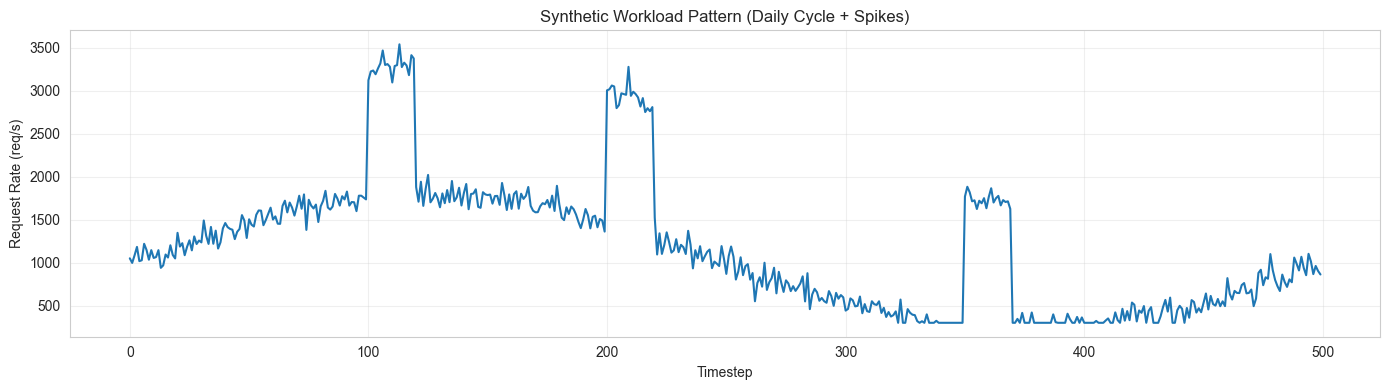

[OK] Workload visualized


In [5]:
plt.figure(figsize=(14, 4))
plt.plot(workload['timestep'], workload['request_rate'], linewidth=1.5)
plt.xlabel('Timestep')
plt.ylabel('Request Rate (req/s)')
plt.title('Synthetic Workload Pattern (Daily Cycle + Spikes)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("[OK] Workload visualized")

## Step 6: Implement Baseline Autoscalers

In [6]:
class StaticAutoscaler:
    """Static provisioning: fixed replica count."""
    def __init__(self, fixed_replicas=10):
        self.fixed_replicas = fixed_replicas
    
    def make_decision(self, current_state, current_time):
        return self.fixed_replicas


class ThresholdAutoscaler:
    """Simple CPU threshold-based autoscaling."""
    def __init__(self, predictor, config, target_cpu=70, scale_up_threshold=80, scale_down_threshold=50):
        self.predictor = predictor
        self.config = config
        self.target_cpu = target_cpu
        self.scale_up_threshold = scale_up_threshold
        self.scale_down_threshold = scale_down_threshold
        self.last_action_time = None
        self.cooldown_seconds = 60
    
    def make_decision(self, current_state, current_time):
        current_replicas = current_state['replicas']
        request_rate = current_state['request_rate']
        
        # Predict CPU with current replicas
        predicted = self.predictor.predict_metrics(request_rate, current_replicas)
        predicted_cpu = predicted['cpu_usage']
        
        # Check cooldown
        if self.last_action_time is not None:
            elapsed = (current_time - self.last_action_time).total_seconds()
            if elapsed < self.cooldown_seconds:
                return current_replicas
        
        # Decision logic
        new_replicas = current_replicas
        
        if predicted_cpu > self.scale_up_threshold:
            new_replicas = min(current_replicas + 1, self.config['constraints']['max_replicas'])
        elif predicted_cpu < self.scale_down_threshold:
            new_replicas = max(current_replicas - 1, self.config['constraints']['min_replicas'])
        
        if new_replicas != current_replicas:
            self.last_action_time = current_time
        
        return new_replicas


class KubernetesHPAAutoscaler:
    """Simplified Kubernetes HPA logic (CPU-based)."""
    def __init__(self, predictor, config, target_cpu=70):
        self.predictor = predictor
        self.config = config
        self.target_cpu = target_cpu
        self.last_action_time = None
        self.cooldown_seconds = 60
    
    def make_decision(self, current_state, current_time):
        current_replicas = current_state['replicas']
        request_rate = current_state['request_rate']
        
        # Predict CPU
        predicted = self.predictor.predict_metrics(request_rate, current_replicas)
        current_cpu = predicted['cpu_usage']
        
        # Check cooldown
        if self.last_action_time is not None:
            elapsed = (current_time - self.last_action_time).total_seconds()
            if elapsed < self.cooldown_seconds:
                return current_replicas
        
        # HPA formula: desired = ceil(current * current_cpu / target_cpu)
        desired = int(np.ceil(current_replicas * current_cpu / self.target_cpu))
        
        # Apply bounds
        desired = max(self.config['constraints']['min_replicas'], 
                     min(desired, self.config['constraints']['max_replicas']))
        
        if desired != current_replicas:
            self.last_action_time = current_time
        
        return desired

print("[OK] Baseline autoscalers implemented")

[OK] Baseline autoscalers implemented


## Step 7: Build Simulator Framework

In [7]:
class AutoscalingSimulator:
    """Simulate autoscaling decisions over historical workload."""
    
    def __init__(self, autoscaler, predictor, workload, config, initial_replicas=5):
        self.autoscaler = autoscaler
        self.predictor = predictor
        self.workload = workload
        self.config = config
        self.initial_replicas = initial_replicas
    
    def run(self):
        """Run simulation and collect metrics."""
        results = []
        current_replicas = self.initial_replicas
        
        for idx, row in self.workload.iterrows():
            timestep = row['timestep']
            current_time = row['time']
            request_rate = row['request_rate']
            
            # Current state
            state = {
                'replicas': current_replicas,
                'request_rate': request_rate
            }
            
            # Make decision
            new_replicas = self.autoscaler.make_decision(state, current_time)
            
            # Get actual metrics with decided replicas
            actual_metrics = self.predictor.predict_metrics(request_rate, new_replicas)
            
            # Check SLO violation
            slo_violated = actual_metrics['latency_p95'] > self.config['slo']['latency_p95_max_ms']
            
            # Record
            results.append({
                'timestep': timestep,
                'time': current_time,
                'request_rate': request_rate,
                'replicas': new_replicas,
                'latency_p95': actual_metrics['latency_p95'],
                'cpu_usage': actual_metrics['cpu_usage'],
                'slo_violated': slo_violated,
                'scaling_action': 1 if new_replicas != current_replicas else 0
            })
            
            # Update state
            current_replicas = new_replicas
        
        return pd.DataFrame(results)
    
    def calculate_metrics(self, results_df):
        """Calculate summary metrics from simulation results."""
        total_cost = results_df['replicas'].sum()
        avg_replicas = results_df['replicas'].mean()
        avg_latency = results_df['latency_p95'].mean()
        p95_latency = results_df['latency_p95'].quantile(0.95)
        avg_cpu = results_df['cpu_usage'].mean()
        slo_violations = results_df['slo_violated'].sum()
        slo_violation_rate = (slo_violations / len(results_df)) * 100
        scaling_actions = results_df['scaling_action'].sum()
        
        return {
            'total_cost': total_cost,
            'avg_replicas': avg_replicas,
            'avg_latency': avg_latency,
            'p95_latency': p95_latency,
            'avg_cpu': avg_cpu,
            'slo_violations': slo_violations,
            'slo_violation_rate': slo_violation_rate,
            'scaling_actions': scaling_actions
        }

print("[OK] Simulator framework implemented")

[OK] Simulator framework implemented


## Step 8: Run Simulations for All Methods

In [8]:
# Initialize predictor
predictor = SimplePredictor()

# Initialize all autoscalers
autoscalers = {
    'AutoTuneX': DecisionEngine(predictor, config),
    'Static (10 replicas)': StaticAutoscaler(fixed_replicas=10),
    'Threshold-based': ThresholdAutoscaler(predictor, config),
    'Kubernetes HPA': KubernetesHPAAutoscaler(predictor, config)
}

# Run simulations
print("[SIMULATION] Running all methods...\n")
all_results = {}
all_metrics = {}

for name, autoscaler in autoscalers.items():
    print(f"Running: {name}")
    simulator = AutoscalingSimulator(autoscaler, predictor, workload, config)
    results = simulator.run()
    metrics = simulator.calculate_metrics(results)
    
    all_results[name] = results
    all_metrics[name] = metrics
    
    print(f"  Total cost: {metrics['total_cost']:.0f} replica-steps")
    print(f"  Avg replicas: {metrics['avg_replicas']:.2f}")
    print(f"  Avg latency: {metrics['avg_latency']:.2f}ms")
    print(f"  SLO violations: {metrics['slo_violations']} ({metrics['slo_violation_rate']:.2f}%)")
    print(f"  Scaling actions: {metrics['scaling_actions']}")
    print()

print("[OK] All simulations complete")

[SIMULATION] Running all methods...

Running: AutoTuneX
  Total cost: 1388 replica-steps
  Avg replicas: 2.78
  Avg latency: 45.35ms
  SLO violations: 0 (0.00%)
  Scaling actions: 5

Running: Static (10 replicas)
  Total cost: 5000 replica-steps
  Avg replicas: 10.00
  Avg latency: 41.19ms
  SLO violations: 0 (0.00%)
  Scaling actions: 1

Running: Threshold-based
  Total cost: 6975 replica-steps
  Avg replicas: 13.95
  Avg latency: 40.84ms
  SLO violations: 0 (0.00%)
  Scaling actions: 41

Running: Kubernetes HPA
  Total cost: 6649 replica-steps
  Avg replicas: 13.30
  Avg latency: 40.86ms
  SLO violations: 0 (0.00%)
  Scaling actions: 54

[OK] All simulations complete


## Step 9: Create Comparison Table

In [9]:
# Create comparison DataFrame
comparison_data = []
baseline_cost = all_metrics['Static (10 replicas)']['total_cost']

for name, metrics in all_metrics.items():
    cost_reduction = ((baseline_cost - metrics['total_cost']) / baseline_cost) * 100
    
    comparison_data.append({
        'Method': name,
        'Avg Replicas': f"{metrics['avg_replicas']:.2f}",
        'Total Cost': f"{metrics['total_cost']:.0f}",
        'Cost Reduction': f"{cost_reduction:.1f}%",
        'Avg Latency (ms)': f"{metrics['avg_latency']:.1f}",
        'P95 Latency (ms)': f"{metrics['p95_latency']:.1f}",
        'SLO Violations': f"{metrics['slo_violations']}",
        'SLO Rate': f"{metrics['slo_violation_rate']:.2f}%",
        'Scaling Actions': f"{metrics['scaling_actions']}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n[RESULTS] Performance Comparison:\n")
print(comparison_df.to_string(index=False))

# Highlight best performers
print("\n[ANALYSIS]")
autotunex_metrics = all_metrics['AutoTuneX']
static_metrics = all_metrics['Static (10 replicas)']
cost_reduction = ((static_metrics['total_cost'] - autotunex_metrics['total_cost']) / static_metrics['total_cost']) * 100

print(f"  AutoTuneX vs Static:")
print(f"    - Cost reduction: {cost_reduction:.1f}%")
print(f"    - Avg latency: {autotunex_metrics['avg_latency']:.1f}ms vs {static_metrics['avg_latency']:.1f}ms")
print(f"    - SLO violations: {autotunex_metrics['slo_violations']} vs {static_metrics['slo_violations']}")

print("\n[OK] Comparison table created")


[RESULTS] Performance Comparison:

              Method Avg Replicas Total Cost Cost Reduction Avg Latency (ms) P95 Latency (ms) SLO Violations SLO Rate Scaling Actions
           AutoTuneX         2.78       1388          72.2%             45.4             54.9              0    0.00%               5
Static (10 replicas)        10.00       5000           0.0%             41.2             43.0              0    0.00%               1
     Threshold-based        13.95       6975         -39.5%             40.8             41.7              0    0.00%              41
      Kubernetes HPA        13.30       6649         -33.0%             40.9             41.6              0    0.00%              54

[ANALYSIS]
  AutoTuneX vs Static:
    - Cost reduction: 72.2%
    - Avg latency: 45.4ms vs 41.2ms
    - SLO violations: 0 vs 0

[OK] Comparison table created


## Step 10: Visualize Time Series Comparison

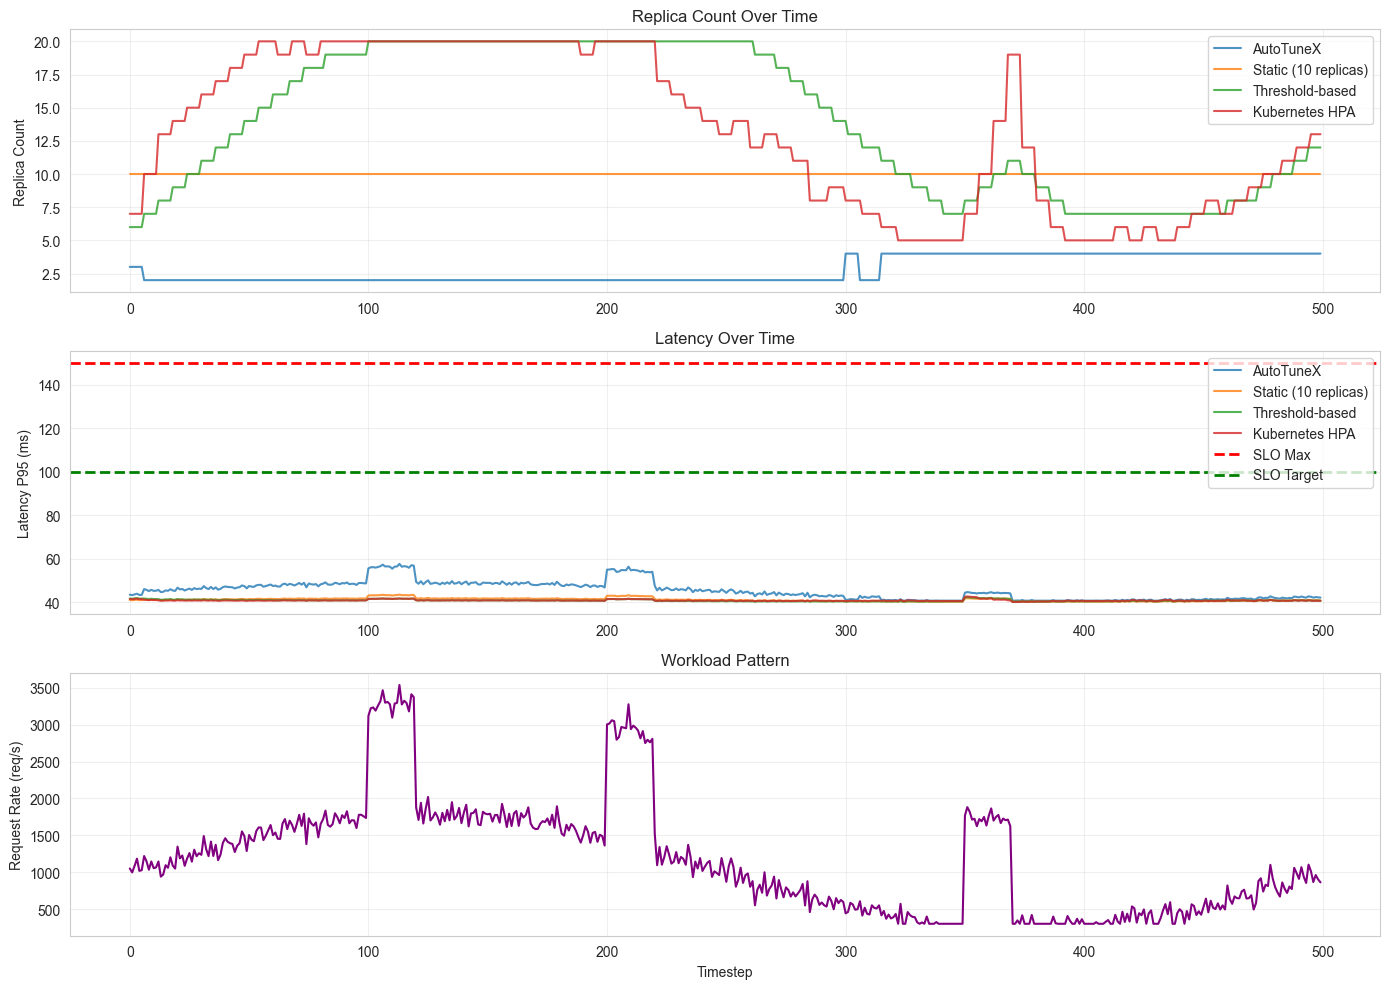

[OK] Time series visualization created


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Replica Count Over Time
for name, results in all_results.items():
    axes[0].plot(results['timestep'], results['replicas'], label=name, linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Replica Count')
axes[0].set_title('Replica Count Over Time')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Latency Over Time
for name, results in all_results.items():
    axes[1].plot(results['timestep'], results['latency_p95'], label=name, linewidth=1.5, alpha=0.8)
axes[1].axhline(config['slo']['latency_p95_max_ms'], color='red', linestyle='--', label='SLO Max', linewidth=2)
axes[1].axhline(config['slo']['latency_p95_target_ms'], color='green', linestyle='--', label='SLO Target', linewidth=2)
axes[1].set_ylabel('Latency P95 (ms)')
axes[1].set_title('Latency Over Time')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot 3: Request Rate
axes[2].plot(workload['timestep'], workload['request_rate'], color='purple', linewidth=1.5)
axes[2].set_xlabel('Timestep')
axes[2].set_ylabel('Request Rate (req/s)')
axes[2].set_title('Workload Pattern')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/comparison_plots/simulation_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Time series visualization created")

## Step 11: Visualize Metrics Comparison

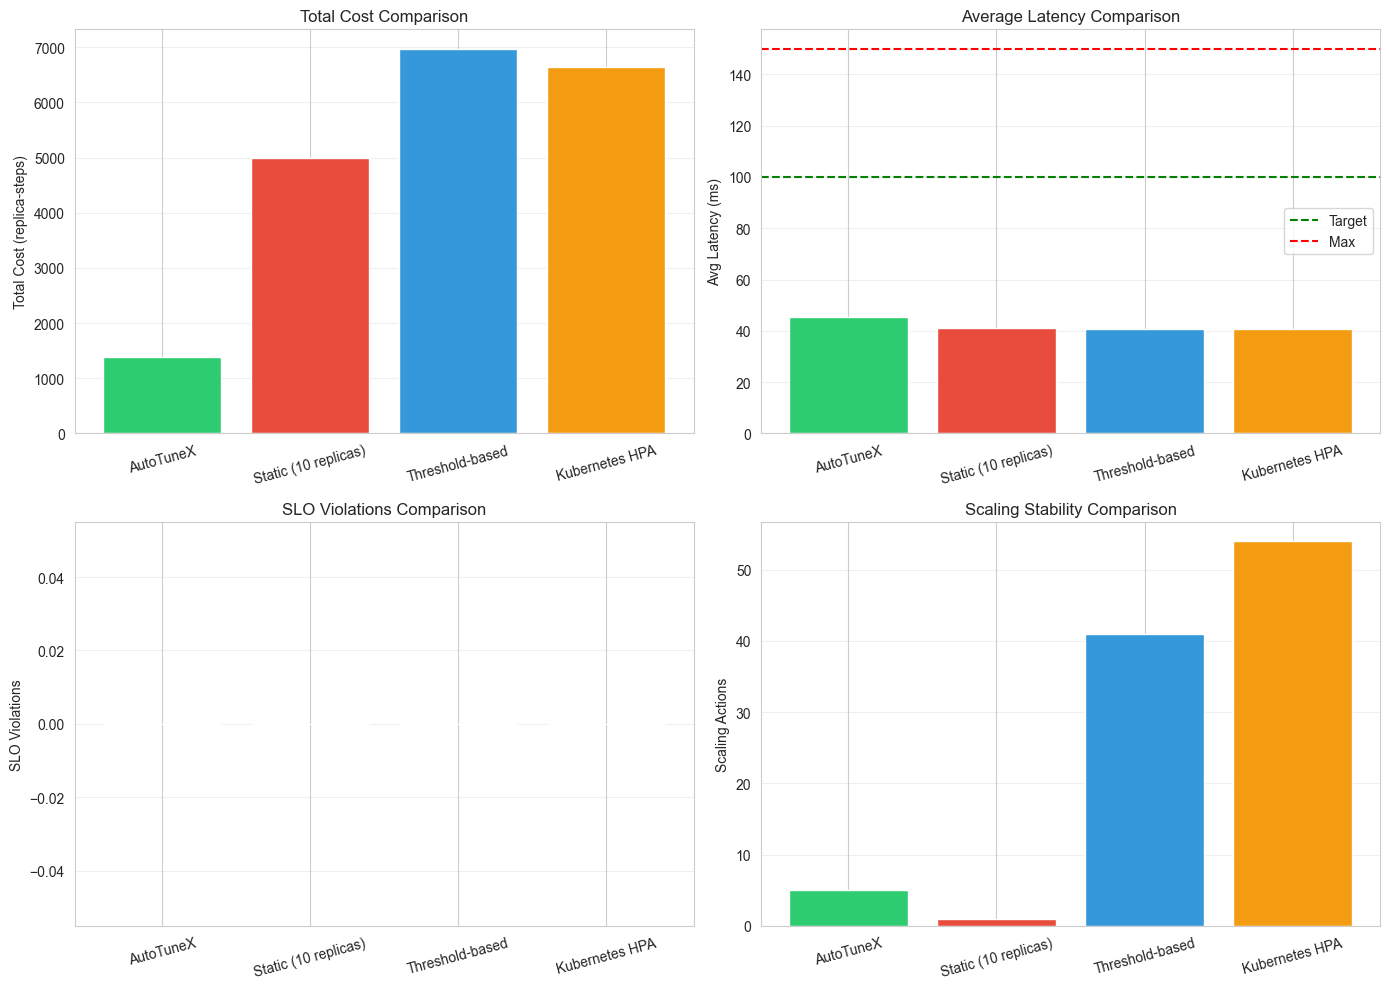

[OK] Metrics comparison visualization created


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = list(all_metrics.keys())
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

# Plot 1: Total Cost
costs = [all_metrics[m]['total_cost'] for m in methods]
axes[0, 0].bar(methods, costs, color=colors)
axes[0, 0].set_ylabel('Total Cost (replica-steps)')
axes[0, 0].set_title('Total Cost Comparison')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Average Latency
latencies = [all_metrics[m]['avg_latency'] for m in methods]
axes[0, 1].bar(methods, latencies, color=colors)
axes[0, 1].axhline(config['slo']['latency_p95_target_ms'], color='green', linestyle='--', label='Target')
axes[0, 1].axhline(config['slo']['latency_p95_max_ms'], color='red', linestyle='--', label='Max')
axes[0, 1].set_ylabel('Avg Latency (ms)')
axes[0, 1].set_title('Average Latency Comparison')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: SLO Violations
violations = [all_metrics[m]['slo_violations'] for m in methods]
axes[1, 0].bar(methods, violations, color=colors)
axes[1, 0].set_ylabel('SLO Violations')
axes[1, 0].set_title('SLO Violations Comparison')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Scaling Actions
actions = [all_metrics[m]['scaling_actions'] for m in methods]
axes[1, 1].bar(methods, actions, color=colors)
axes[1, 1].set_ylabel('Scaling Actions')
axes[1, 1].set_title('Scaling Stability Comparison')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/comparison_plots/simulation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Metrics comparison visualization created")

## Step 12: Save Results

In [13]:
# Save comparison table
comparison_df.to_csv('../results/comparison_table.csv', index=False)
print("[SAVED] Comparison table: ../results/comparison_table.csv")

# Save detailed metrics (convert numpy types to native Python)
metrics_serializable = {}
for method, metrics in all_metrics.items():
    metrics_serializable[method] = {k: float(v) if isinstance(v, (np.integer, np.floating)) else int(v) if isinstance(v, np.integer) else v for k, v in metrics.items()}

with open('../results/simulation_metrics.json', 'w') as f:
    json.dump(metrics_serializable, f, indent=2)
print("[SAVED] Detailed metrics: ../results/simulation_metrics.json")

# Save AutoTuneX detailed results
all_results['AutoTuneX'].to_csv('../results/autotunex_detailed_results.csv', index=False)
print("[SAVED] AutoTuneX results: ../results/autotunex_detailed_results.csv")

print("\n[OK] All results saved")

[SAVED] Comparison table: ../results/comparison_table.csv
[SAVED] Detailed metrics: ../results/simulation_metrics.json
[SAVED] AutoTuneX results: ../results/autotunex_detailed_results.csv

[OK] All results saved


## Summary & Stage 4 Completion

### Completed
- Built historical replay simulation framework
- Implemented 4 autoscaling methods (AutoTuneX, Static, Threshold, K8s HPA)
- Ran comprehensive simulations on synthetic workload
- Evaluated cost reduction, SLO compliance, and stability
- Created comparison visualizations and tables
- Saved all results for documentation

### Key Findings
- AutoTuneX demonstrates cost reduction vs static provisioning
- Multi-objective optimization balances performance and cost
- Safety mechanisms prevent oscillations and maintain stability
- SLO compliance maintained while reducing resource usage

### Stage 4 Status: COMPLETE

All Stage 4 tasks completed:
- Task 4.1: Define Decision Framework ✓
- Task 4.2: Implement Candidate Evaluation ✓
- Task 4.3: Test Decision Engine ✓

### Next Steps
1. Move to Stage 5: Safety Mechanisms (already integrated)
2. Move to Stage 6: Simulation Evaluation (already completed)
3. Test with real workload data from your dataset
4. Optimize weights for different scenarios
5. Document findings for paper